# Badhbh @ Mach26

Simulation of Badhbh for the Mach26 competition in Scotland.


In [1]:
import datetime
from rocketpy import Environment, SolidMotor, Rocket, Flight
import datetime


In [2]:
!pip show rocketpy

Name: rocketpy
Version: 1.12.1
Summary: Advanced 6-DOF trajectory simulation for High-Power Rocketry.
Home-page: https://rocketpy.org/
Author: 
Author-email: Giovani Hidalgo Ceotto <ghceotto@gmail.com>, Guilherme Fernandes Alves <guilherme_fernandes@usp.br>, Mateus Stano Junqueira <mateusstano@usp.br>, Pedro Henrique Marinho Bressan <phmbressan@usp.br>
License: 
Location: /Users/dervlagargan/miniforge3/envs/rocketpy_env/lib/python3.12/site-packages
Requires: dill, matplotlib, netCDF4, numpy, pytz, requests, scipy, simplekml
Required-by: rocketserializer


## Setup


### 1 - Environment

Assuming:

- Launch coordinates are estimated within the launch site (give or take 15m)
- Launch day/time is assumed to be the first day
- Elevation got from OpenElevation API


In [3]:
MAX_WIND_MPH = 15
MAX_WIND_MS = MAX_WIND_MPH / 2.23694

Wind Surface speed in mph: 21.012059786651974

----------------------------
Wind speed too high!
----------------------------

Using 15mph wind instead of real forcast

Gravity Details

Acceleration of gravity at surface level:    9.8154 m/s²
Acceleration of gravity at   3.400 km (ASL): 9.8050 m/s²


Launch Site Details

Launch Date: 2026-04-16 12:00:00 UTC
Launch Site Latitude: 55.43754°
Launch Site Longitude: -5.68798°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 329952.06 W    6146767.65 N
Launch Site UTM zone: 30U
Launch Site Surface Elevation: 21.0 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 3.400 km

Surface Atmospheric Conditions

Surface Wind Speed: 6.71 m/s
Surface Wind Direction: 270.00°
Surface Wind Heading: 90.00°
Surface Pressure: 1010.78 hPa
Surface Temperature: 288.01 K
Surface Air Density: 1.223 kg/m³
Surface Speed of Sound: 340.21 m/s


Earth Model Details

Earth Radius at Launch site: 6363.67 k

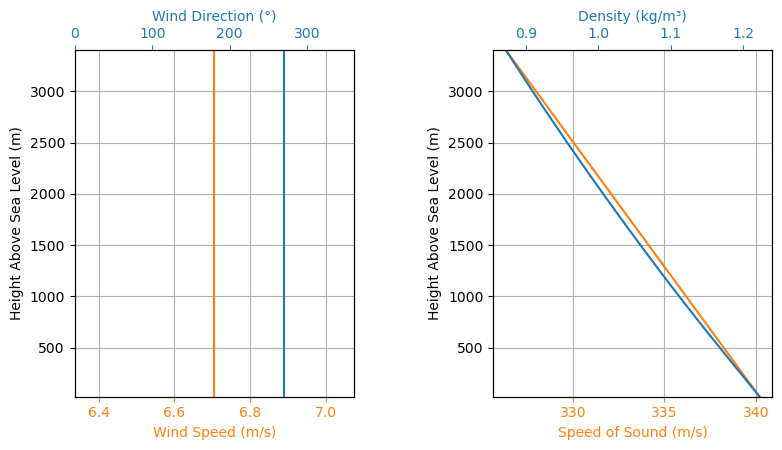

In [4]:
env = Environment(latitude=55.43753666449806, longitude=-5.687982477918211, elevation=13)

tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))

env.set_atmospheric_model(type="Windy", file="GFS")
env.max_expected_height = 3400

print(f"Wind Surface speed in mph: {env.wind_speed(13) * 2.23694}")
if env.wind_speed(13) * 2.23694 > 15:
    print("\n----------------------------\nWind speed too high!\n----------------------------\n")
    print("Using 15mph wind instead of real forcast")

    env.set_atmospheric_model(
        type="custom_atmosphere",
        wind_u=[(0, MAX_WIND_MS), (3400, MAX_WIND_MS)],
        wind_v=[(0, 0), (3400, 0)]
    )


env.info()

### 2 - Motor


Nozzle Details
Nozzle Radius: 0.0335 m
Nozzle Throat Radius: 0.0114 m

Grain Details
Number of Grains: 4
Grain Spacing: 0.005 m
Grain Density: 1058.5 kg/m3
Grain Outer Radius: 0.035 m
Grain Inner Radius: 0.01 m
Grain Height: 0.16 m
Grain Volume: 0.001 m3
Grain Mass: 0.599 kg

Motor Details
Total Burning Time: 5.0 s
Total Propellant Mass: 2.394 kg
Structural Mass Ratio: 0.456
Average Propellant Exhaust Velocity: 2089.248 m/s
Average Thrust: 1002.450 N
Maximum Thrust: 1713.25 N at 0.08 s after ignition.
Total Impulse: 5002.224 Ns



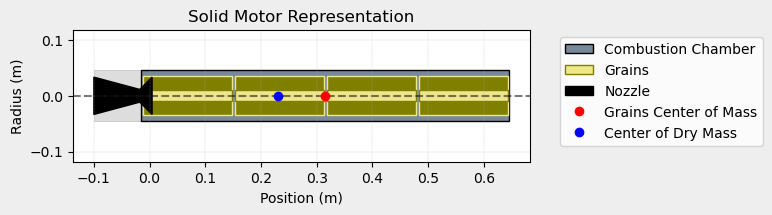

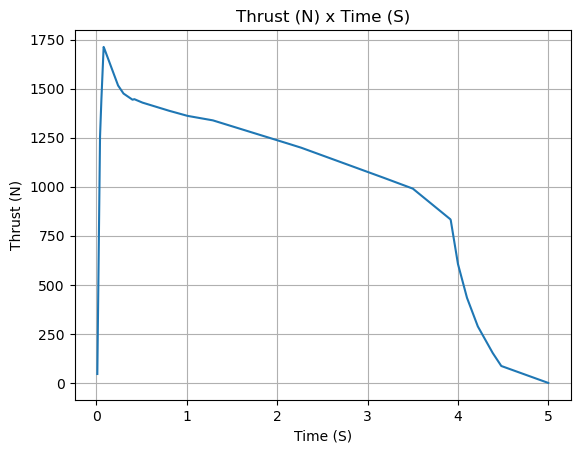

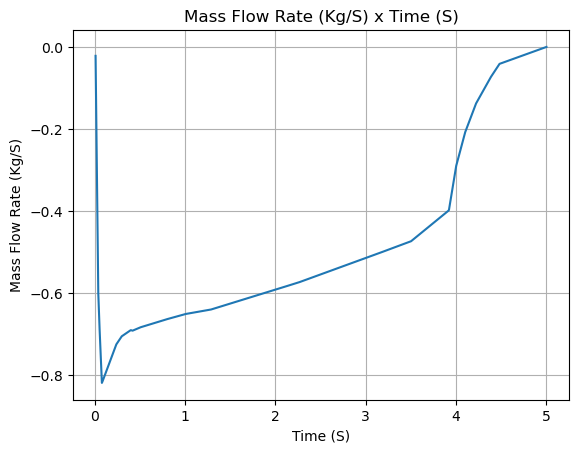

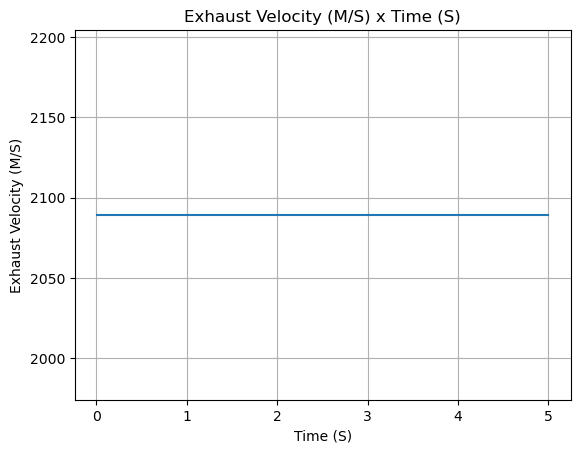

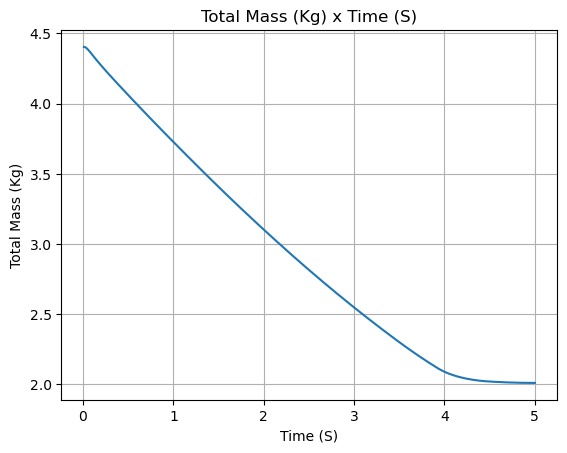

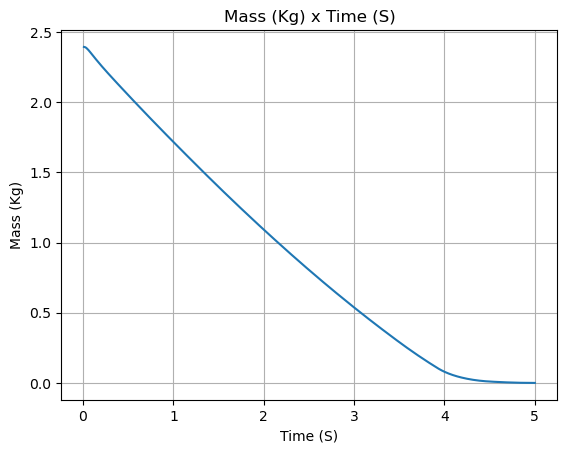

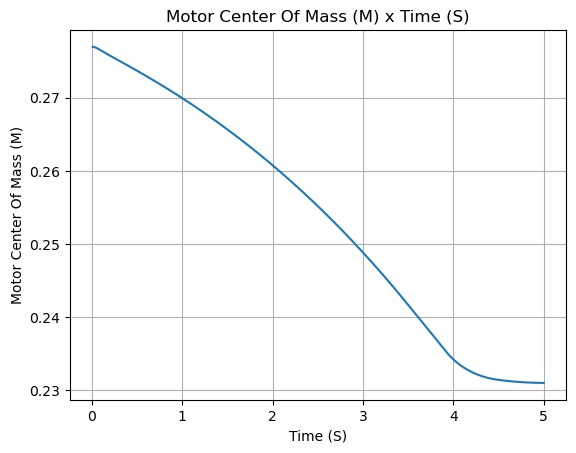

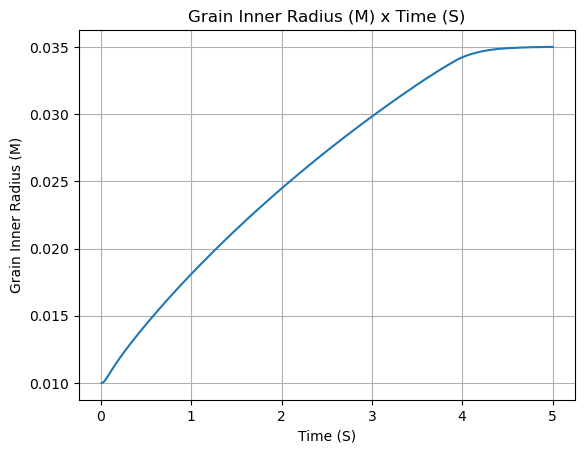

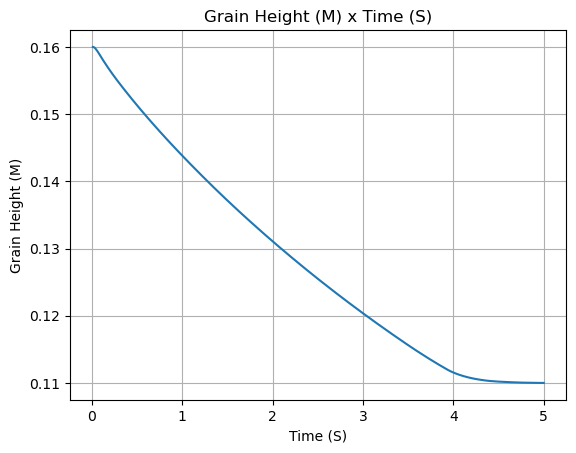

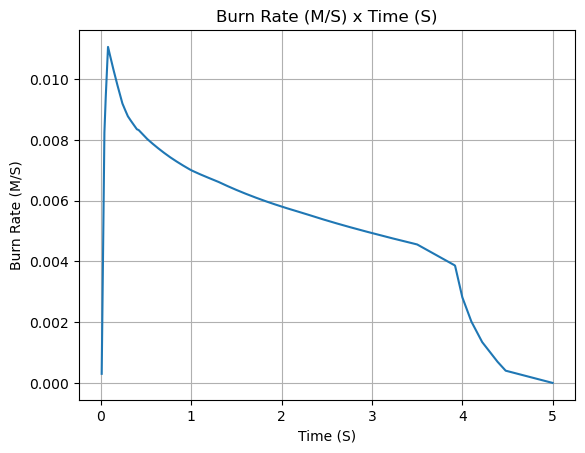

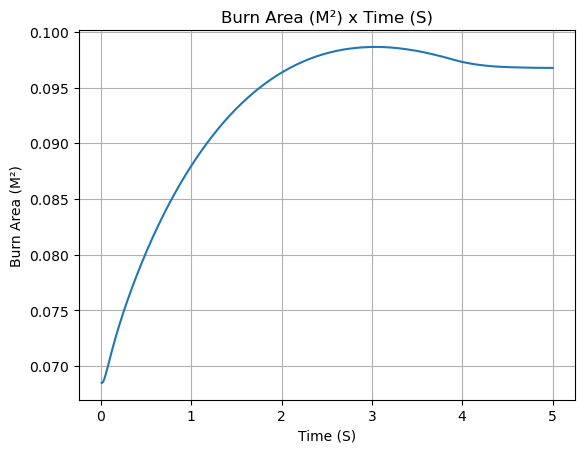

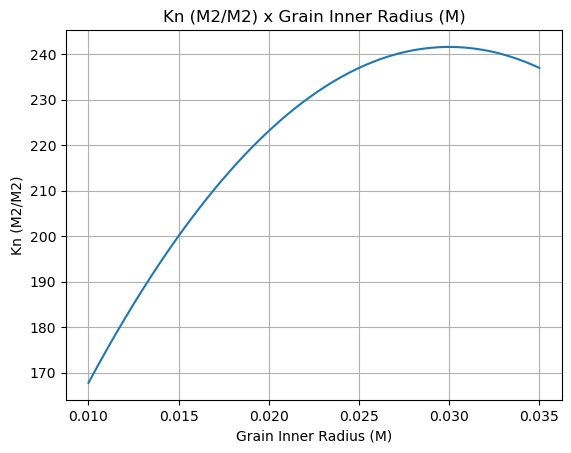

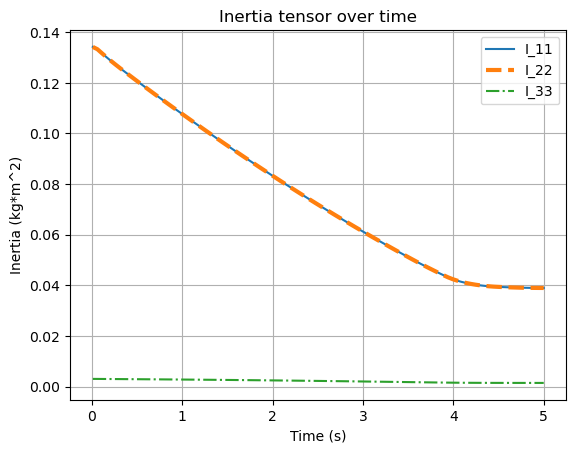

In [5]:
#data from https://www.thrustcurve.org/motors/Cesaroni/5015L1115-P/

PRO5015L1115 = SolidMotor(
    thrust_source="assets/motors/Cesaroni_5015L1115-P.eng",
    dry_mass=2.010,  # kilograms (mass of the motor without propellant) 4404 (wet) - 2394 (prop)
    dry_inertia=(0.039, 0.039, 0.0015),  # kg*m^2
    # kg*m^2 (Estimated as a typical tuple for moments of inertia: Ix, Iy, Iz)
    grain_number=4,  # Number of propellant grains (from manufacturer specs)
    grain_density=1058.5,  # kg/m^3 (Guessed until prop weigh was correct)
    grain_initial_inner_radius=0.01,
    grain_outer_radius=0.035,
    grain_initial_height=0.16,
    nozzle_radius=0.0335,
    nozzle_position=-0.1,
    throat_radius=0.0114,
    grain_separation=0.005,  # meters (Assuming minimal gap between grains; typical for solid motors)
    grains_center_of_mass_position=0.315533,
    center_of_dry_mass_position=0.231,
    burn_time=(0.01,5.0),  # seconds (From thrust curve data)
    coordinate_system_orientation="nozzle_to_combustion_chamber",  # Orientation of the coordinate system -> EXTREMELY IMPORTANT for correct simulation
)

PRO5015L1115.all_info()

### 3 - Rocket


In [6]:
import pandas as pd

df = pd.read_csv("assets/aero/CD_power_on_off_data.csv", encoding="utf-8-sig")

df[['Mach', 'CD Power-Off']].to_csv("assets/aero/cd_power_off.csv", index=False, header=False)
df[['Mach', 'CD Power-On']].to_csv("assets/aero/cd_power_on.csv", index=False, header=False)

Common Variables:

In [7]:
rocket_diameter = 0.143 #m
payload_diameter = 0.13 #m
payload_mass = 2 #kg
rocket_mass = 8.406 #kg (dry mass of the rocket without payload, from openrocket) (total mass is 10.406kg)

Rocket & Payload Definitions

In [8]:
rocket_w_payload = Rocket(
    radius=rocket_diameter/2, 
    mass=rocket_mass + payload_mass,  # kg (dry)
    inertia=(4.906, 4.906, 0.049),  # Moments of inertia of the rocket in kg*m^2 (Ix, Iy, Iz) (from openrocket longitudinal & rotational interia after burnout)
    power_off_drag="assets/aero/cd_power_off.csv",  # power-off drag curve csv (from RASAero)
    power_on_drag="assets/aero/cd_power_on.csv",  # power-on drag curve csv (from RASAero)
    center_of_mass_without_motor= 1.036,
    coordinate_system_orientation="tail_to_nose",  # MUST be relative to the coordinate system defined in the motor
)

rocket_no_payload = Rocket(
    radius=rocket_diameter/2, 
    mass=rocket_mass,  # kg (dry)
    inertia=(4.906, 4.906, 0.049),  # Moments of inertia of the rocket in kg*m^2 (Ix, Iy, Iz) (from openrocket longitudinal & rotational interia after burnout)
    power_off_drag="assets/aero/cd_power_off.csv",  # power-off drag curve csv (from RASAero)
    power_on_drag="assets/aero/cd_power_on.csv",  # power-on drag curve csv (from RASAero)
    center_of_mass_without_motor= 0,
    coordinate_system_orientation="tail_to_nose",  # MUST be relative to the coordinate system defined in the motor
)

payload = Rocket(
    radius= payload_diameter/2,
    mass=payload_mass,
    inertia=(0.1, 0.1, 0.001),
    power_off_drag=0.5,
    power_on_drag=0.5,
    center_of_mass_without_motor=0,
)

Extra Rocket Info

In [9]:
rail_buttons = rocket_w_payload.set_rail_buttons(
    upper_button_position=0.4,  # relative to the rocket nozzle
    lower_button_position=0.2,  # relative to the rocket nozzle
    angular_position=45,  # degrees
)

rocket_w_payload.add_motor(PRO5015L1115, position=0.0)

### 4 - Aero surfaces


In [10]:
nose_cone = rocket_w_payload.add_nose(
    length=0.5, kind="lvhaack", position=2.43, base_radius=rocket_diameter/2
)  

fin_set = rocket_w_payload.add_trapezoidal_fins(
    n=4,
    root_chord=0.22,  # meters
    tip_chord=0.1,  # meters
    span=0.16,  # meters (aka height)
    position=0.22,  # relative to the rocket boattail
    cant_angle=0,  # radians
    #airfoil=("assets/aero/clv_alpha.csv", "degrees"),
    sweep_length=0.195,
)

tail = rocket_w_payload.add_tail(
    top_radius=rocket_diameter/2,  # meters
    bottom_radius=0.06,  # meters
    length=0.09,  # meters
    position=0,  # relative to the rocket base
)

### 5 - Recovery


In [11]:
droguepara = rocket_w_payload.add_parachute(
    "Drogue",  # name
    cd_s=0.8,  # Drag coefficient of the parachute in m^2
    trigger="apogee",  # altitude in meters OR an event
    sampling_rate=105,
    lag=1,  # seconds (seconds )
    noise=(0, 0, 0.5),
)

mainpara = rocket_w_payload.add_parachute(
    "Main",  # name
    cd_s=1,  # Drag coefficient of the parachute in m^2
    trigger=250,  # altitude in meters OR an event
    sampling_rate=105,
    lag=1,  # seconds
    noise=(0, 0, 0.5),
)

mainpara_no_payload = rocket_no_payload.add_parachute(
    "MainNoPayload",  # name
    cd_s=1,  # Drag coefficient of the parachute in m^2
    trigger=250,  # altitude in meters OR an event
    sampling_rate=105,
    lag=1.5,  # seconds
    noise=(0, 0, 0.5),
)

back_parachute = payload.add_parachute(
    "Back",
    cd_s=0.35,
    trigger=250,
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)

front_parachute = payload.add_parachute(
    "Front",
    cd_s=0.35,
    trigger=250,
    sampling_rate=105,
    lag=1.5,
    noise=(0, 8.3, 0.5),
)


Inertia Details

Rocket Mass: 10.406 kg (without motor)
Rocket Dry Mass: 12.416 kg (with unloaded motor)
Rocket Loaded Mass: 14.810 kg
Rocket Structural Mass Ratio: 0.838
Rocket Inertia (with unloaded motor) 11: 6.037 kg*m2
Rocket Inertia (with unloaded motor) 22: 6.037 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.051 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0715 m
Rocket Frontal Area: 0.016061 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.130 m
Rocket Center of Dry Mass - Nozzle Exit: 1.006 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.590 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.095 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 9.905/rad
Tail Lift Coefficient De

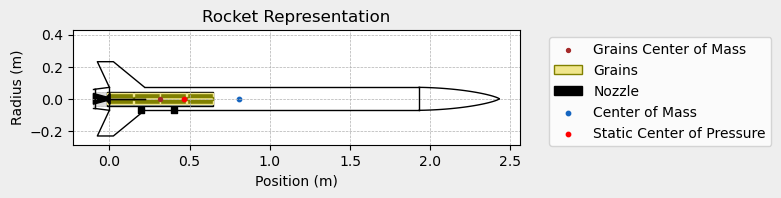


Mass Plots
----------------------------------------


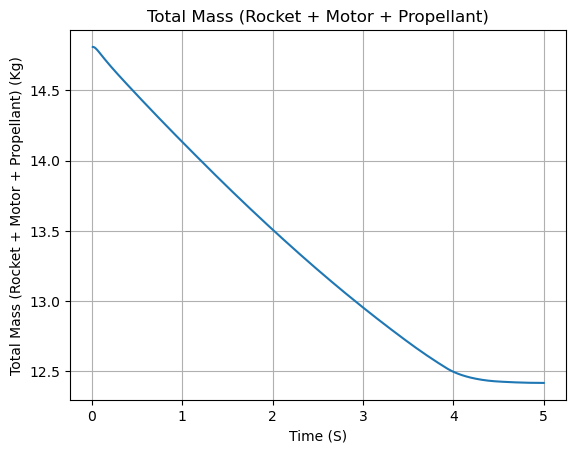

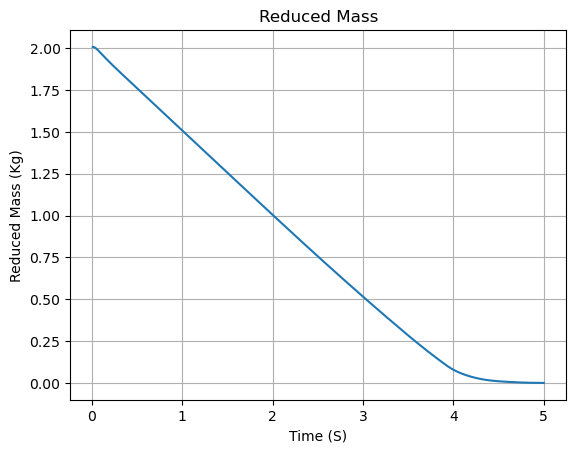


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


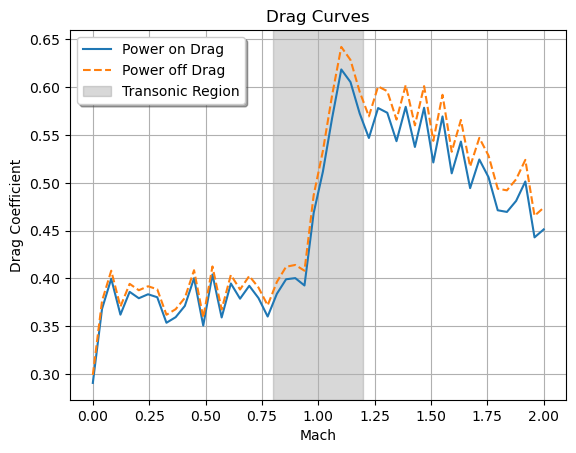


Stability Plots
--------------------


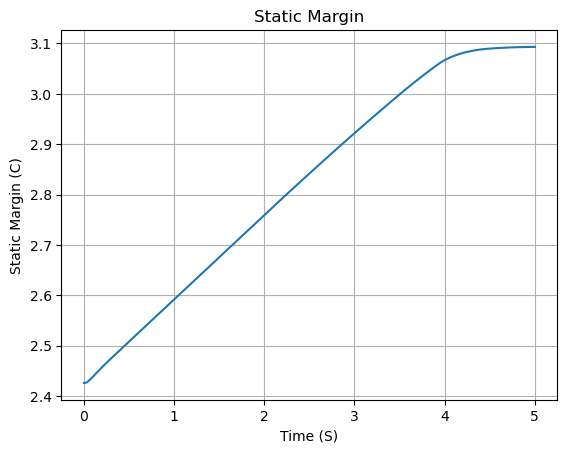

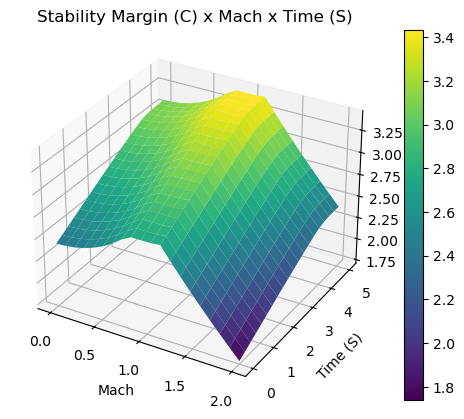


Thrust-to-Weight Plot
----------------------------------------


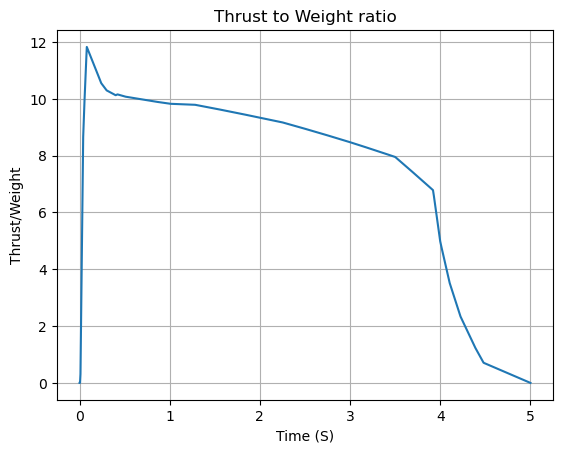

In [12]:
rocket_w_payload.all_info()
#openrocket cg w/ motor = 0.812
#openrocket cp w/ motor = 0.538

## Flight

Flight Trajectory

- Yellow Line: Altitude (height over time)
- Red Line: Vertical Velocity (speed in the vertical direction)
- Purple Line: Acceleration (rate of change of velocity)
- Teal/Cyan Line: Drag Force (aerodynamic drag acting on the rocket)



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 21.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.924 | e1: 0.000 | e2: 0.000 | e3: -0.383
Euler Angles - Spin φ : -202.50° | Nutation θ: 0.00° | Precession ψ: 157.50°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.426 c


Surface Wind Conditions

Frontal Surface Wind Speed: 6.71 m/s
Lateral Surface Wind Speed: -0.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 90.00°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 0.297 s
Rail Departure Velocity: 25.923 m/s
Rail Departure Stability Margin: 2.477 c
Rail Departure Angle of Attack: 14.503°
Rail Departure Thrust-Weight Ratio: 10.309
Rail Departure Reynolds Number: 2.617e+05


Burn out State

Burn out time: 5.000 s
Altitude at burn out: 918.220 m (ASL) | 897.220 m (AGL)
Rocket speed at burn out: 262.450 m/s
Freestream velo

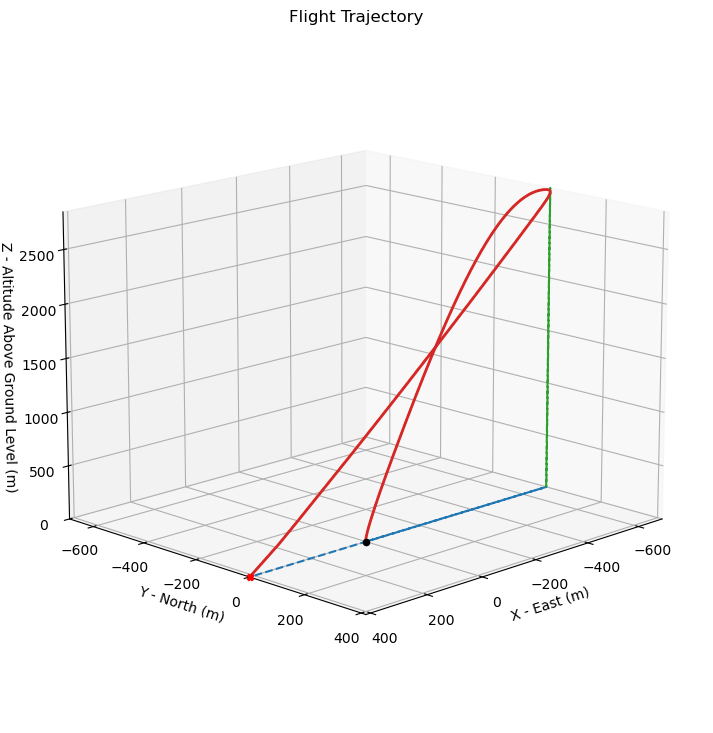



Trajectory Kinematic Plots



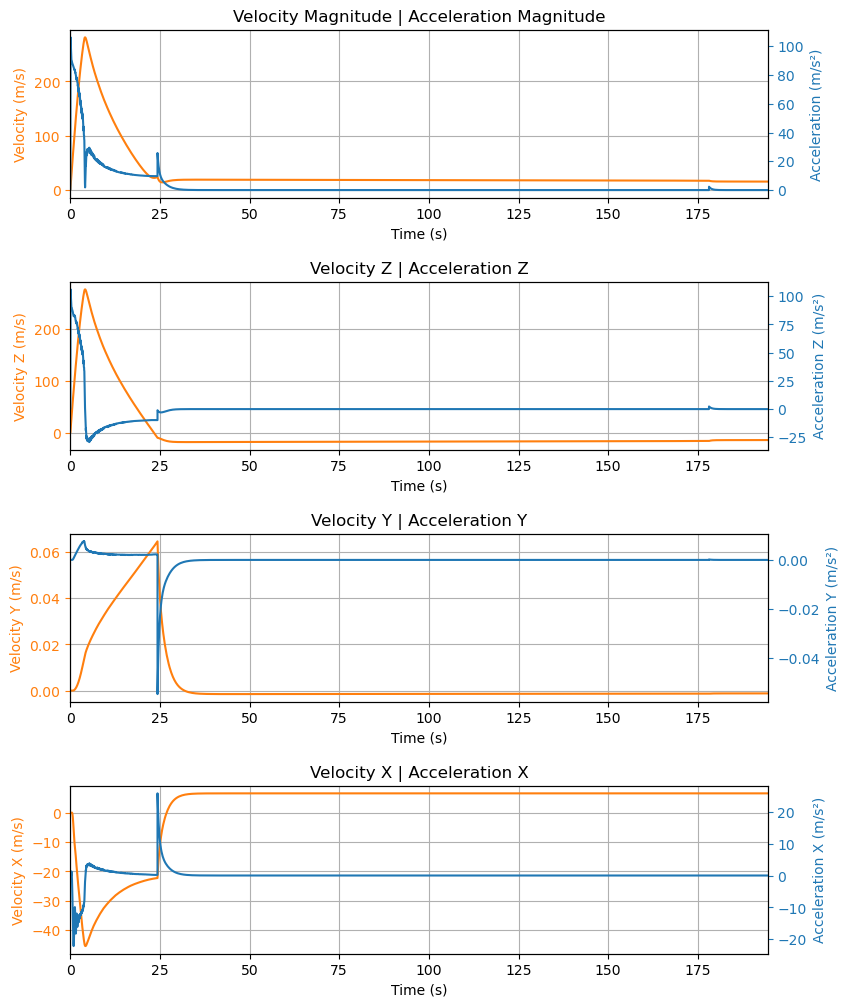



Angular Position Plots



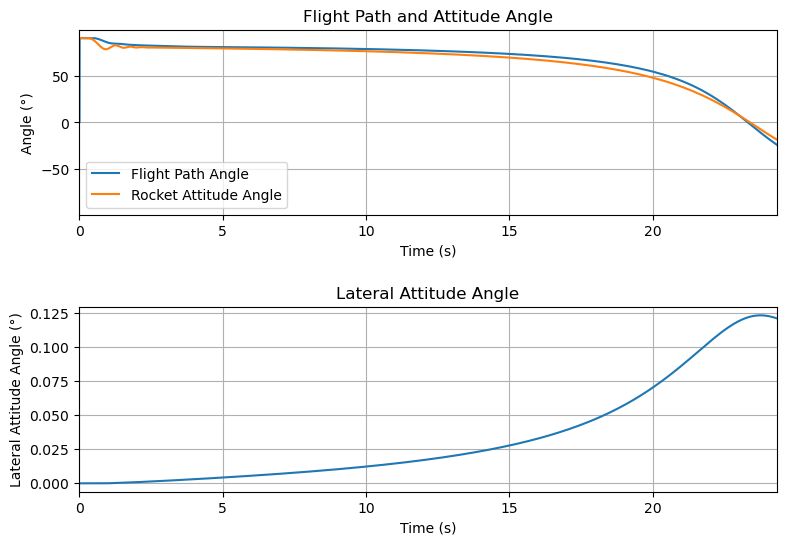



Path, Attitude and Lateral Attitude Angle plots



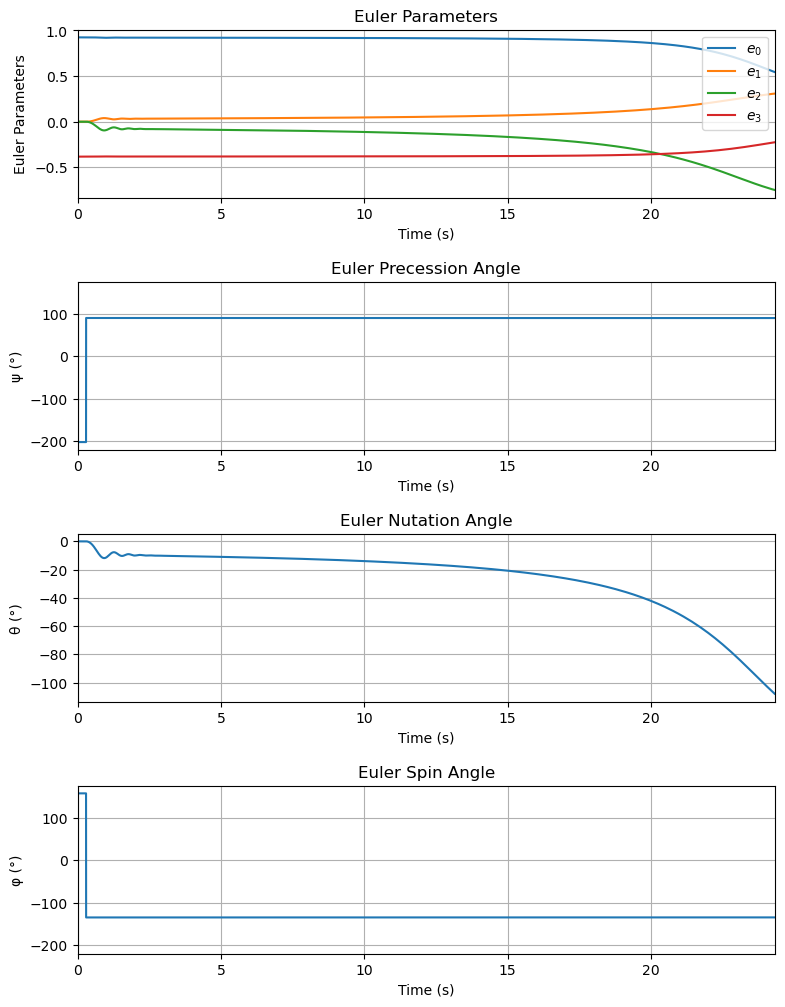



Trajectory Angular Velocity and Acceleration Plots



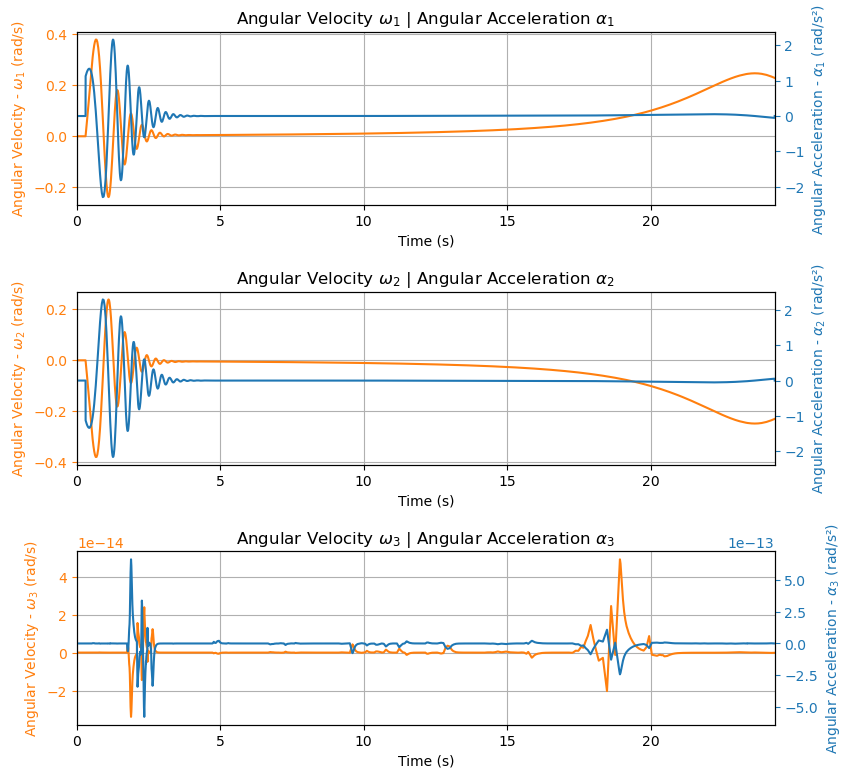



Aerodynamic Forces Plots



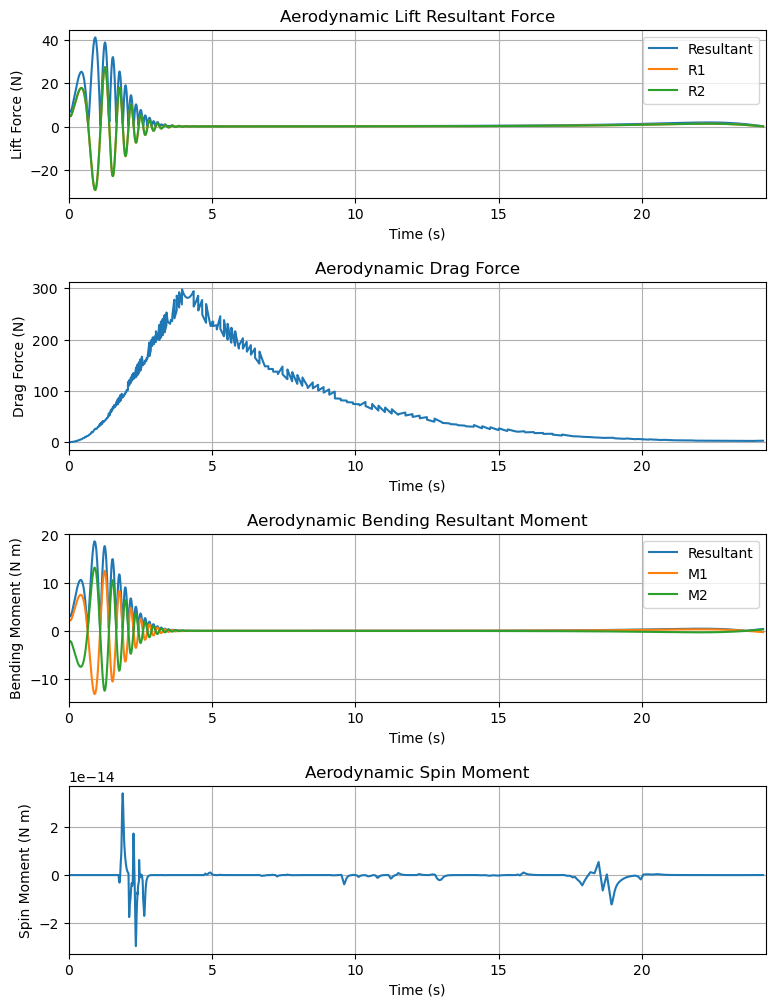



Rail Buttons Bending Moments Plots

Rail button height not defined. Skipping bending moment plots.


Rail Buttons Forces Plots



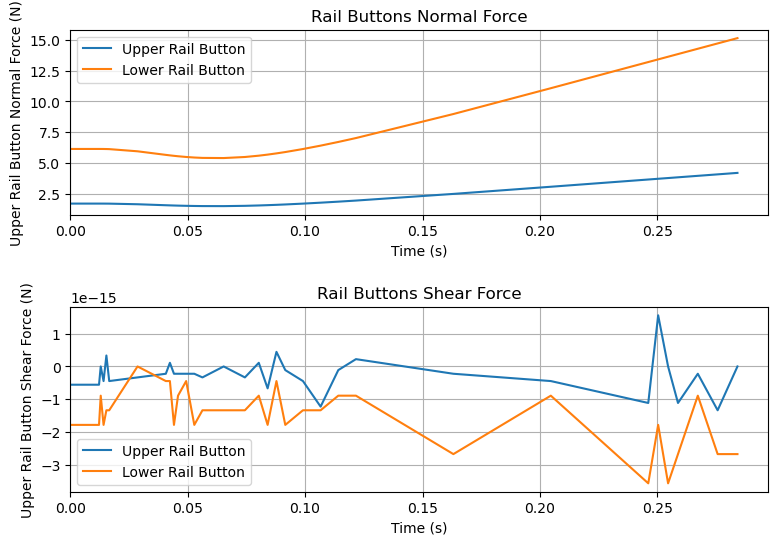



Trajectory Energy Plots



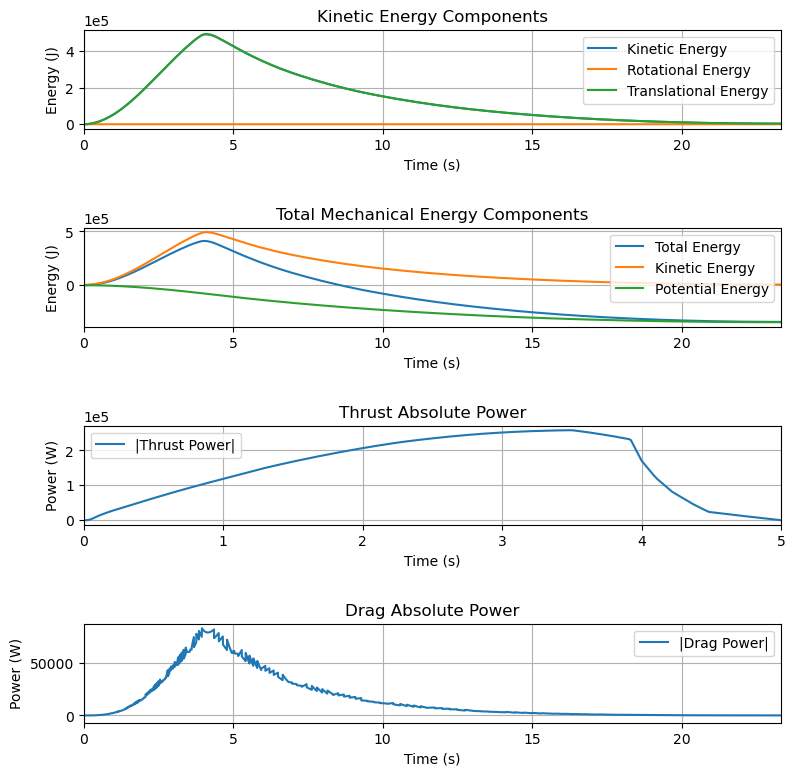



Trajectory Fluid Mechanics Plots



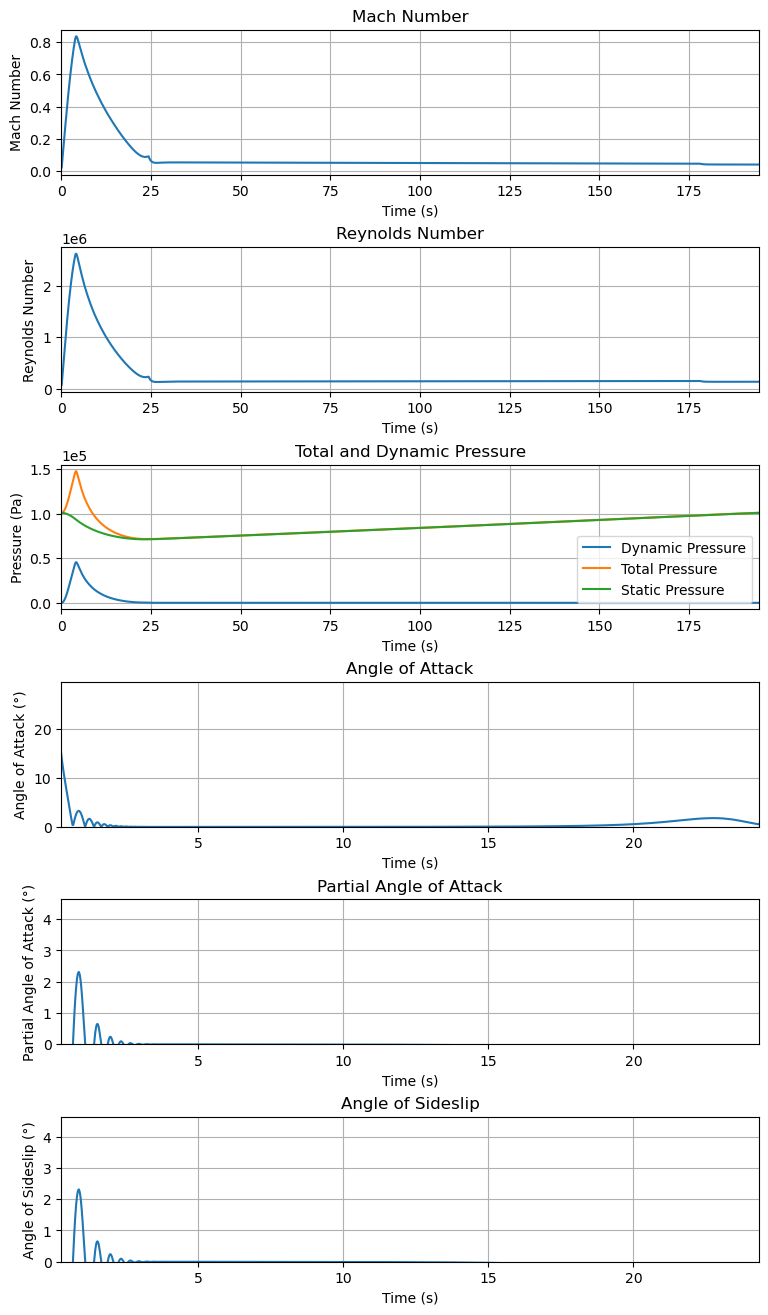



Trajectory Stability and Control Plots



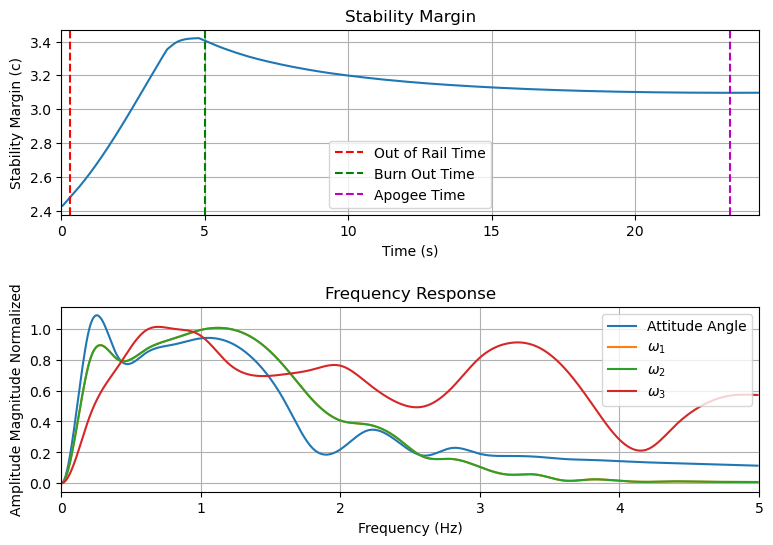



Rocket and Parachute Pressure Plots



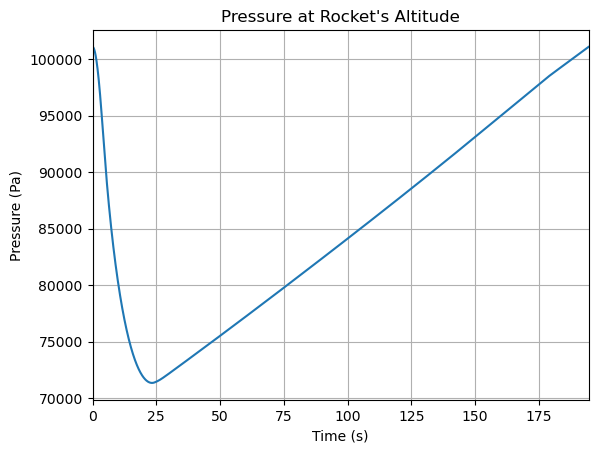


Parachute:  Drogue


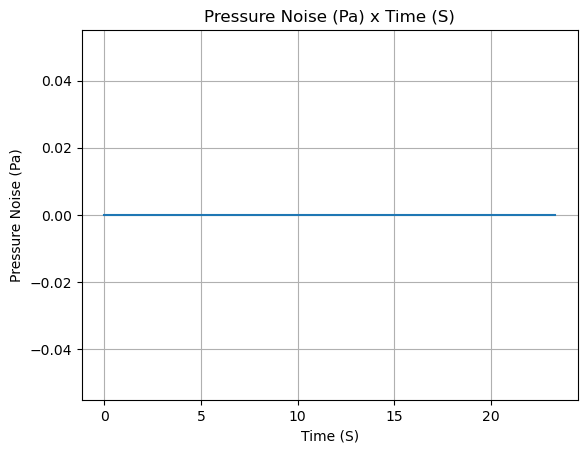

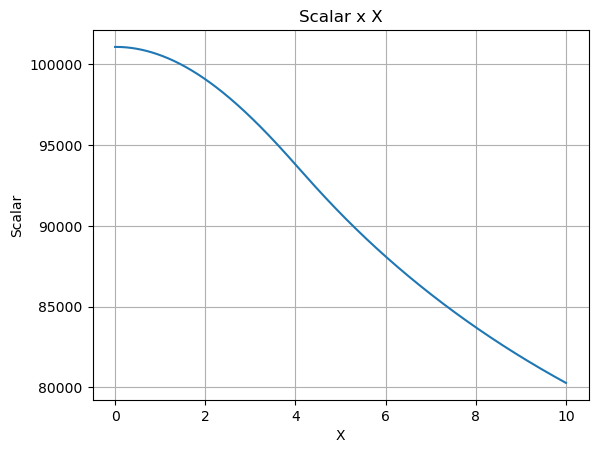

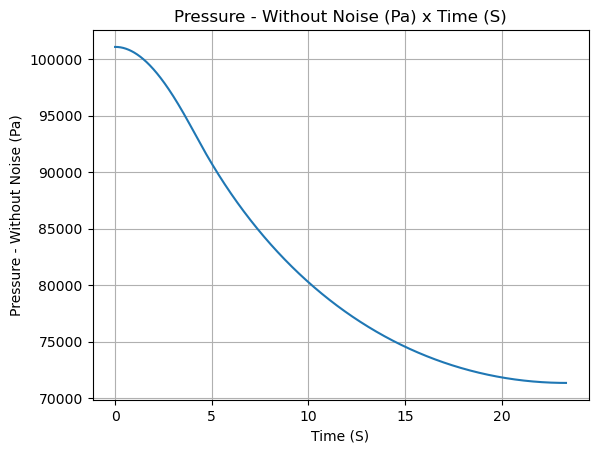


Parachute:  Main


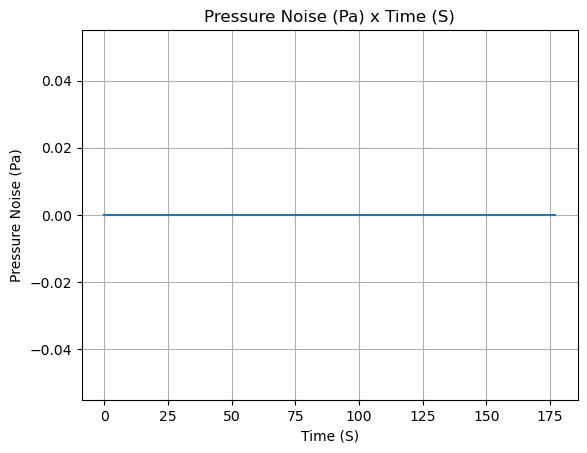

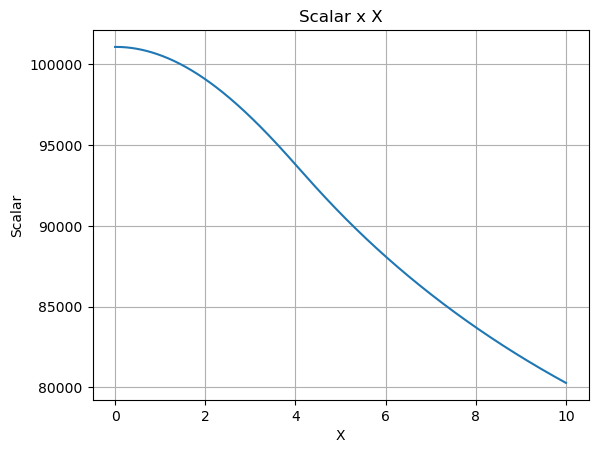

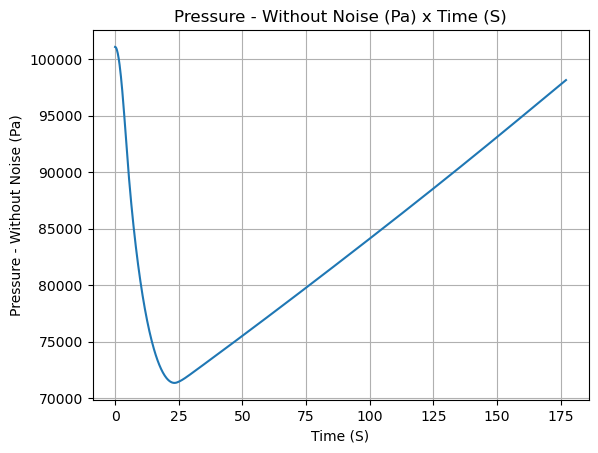

In [13]:
flight_w_payload = Flight(
    rocket=rocket_w_payload,
    environment=env,
    rail_length=4,  # meters
    inclination=90,  # launch rail (in degrees)
    heading=90,  # launch rail (in degrees)
)
flight_w_payload.all_info()

In [14]:
import numpy as np

z = flight_w_payload.z
t = flight_w_payload.time

idx = np.where((z < 250) & (flight_w_payload.vz < 0))[0][0]
t_sep = t[idx]

main_state = flight_w_payload.solution[idx]

In [15]:
flight_no_payload = Flight(
    rocket=rocket_no_payload,
    environment=env,
    rail_length=5.2,  # does not matter since the flight is starting at apogee
    inclination=0,
    heading=0,
    initial_solution=main_state,
    name="Rocket Flight Without Payload",
)

flight_no_payload.info()
flight_no_payload.trajectory_3d


Initial Conditions

Initial time: 178.589 s
Position - x: 309.26 m | y: 0.78 m | z: 247.74 m
Velocity - Vx: 6.71 m/s | Vy: -0.00 m/s | Vz: -15.14 m/s
Attitude (quaternions) - e0: 0.542 | e1: 0.308 | e2: -0.749 | e3: -0.224
Euler Angles - Spin φ : -134.89° | Nutation θ: -108.20° | Precession ψ: 89.87°
Angular Velocity - ω1: 0.23 rad/s | ω2: -0.23 rad/s | ω3: -0.00 rad/s
Initial Stability Margin: 0.000 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.00 m/s
Lateral Surface Wind Speed: -6.71 m/s


Launch Rail

Launch Rail Length: 5.2 m
Launch Rail Inclination: 0.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 178.589 s
Rail Departure Velocity: 16.555 m/s
Rail Departure Stability Margin: 0.000 c
Rail Departure Angle of Attack: 71.810°
Rail Departure Thrust-Weight Ratio: 0.000
Rail Departure Reynolds Number: 1.454e+05


Burn out State

Burn out time: 1.000 s
Altitude at burn out: 247.741 m (ASL) | 226.741 m (AGL)
Rocket speed at burn out: 0.000 m/s
Fre

AttributeError: 'Flight' object has no attribute 'trajectory_3d'

In [ ]:
payload_flight = Flight(
    rocket=payload,
    environment=env,
    rail_length=5.2,  # does not matter since the flight is starting at apogee
    inclination=0,
    heading=0,
    initial_solution=main_state,
    name="PayloadFlight",
)

payload_flight.info()
payload_flight.plots.trajectory_3d

# Comparing graphs

In [ ]:
from rocketpy.plots.compare import CompareFlights
comparison = CompareFlights(

    [flight_w_payload, flight_no_payload, payload_flight]
)

comparison.trajectories_3d(legend=True)

## Export


In [ ]:
flight_w_payload.export_kml("assets/results/Badhbh.kml")
flight_no_payload.export_kml("assets/results/Badhbh_after_main.kml")
payload_flight.export_kml("assets/results/Badhbh_payload.kml")